# Programming Assignment 1 — Segmentação de Instâncias

Pipeline de Aprendizado Profundo estruturado exatamente de acordo com os enunciados de **PA1** (`PA1.pdf`):
- **Parte 0**: Teste Unitário Sintético (Elipses 128x128).
- **Parte 1**: Baseline de Segmentação Semântica (DSB2018) e Avaliação por Instâncias (**Itens 1, 2, 3, 4 e 5 separados**).

In [92]:
# Setup: Auto-reload e Dispositivo
%load_ext autoreload
%autoreload 2

import os, sys, importlib, torch
sys.path.append(os.path.abspath('src'))
import utils
importlib.reload(utils)

device = utils.get_device()
print(f"Dispositivo: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dispositivo: mps


In [93]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")


Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético
> **Enunciado Parte 0:** *Gerar dataset sintético de 100 imagens 128x128 com 5 a 20 elipses. Treinar em menos de 5 minutos e reportar a métrica.*

In [94]:
# Parte 0 — Dataset Sintético (100 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")


Dataset Sintético | Treino: 70 | Val: 15 | Teste: 15


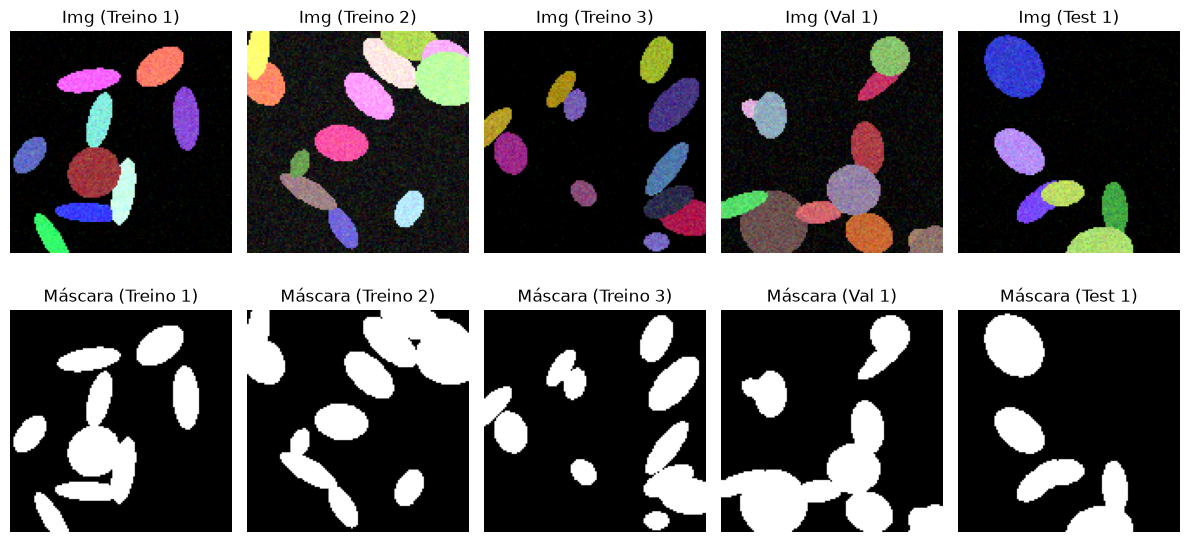

In [95]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)


In [96]:
# Parte 0 — Treinamento Rápido U-Net (< 5 min)
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)


Epoch [ 1/10] | Train Loss: 0.4282 | Val Loss: 0.5325
Epoch [ 2/10] | Train Loss: 0.2662 | Val Loss: 0.3379
Epoch [ 3/10] | Train Loss: 0.2343 | Val Loss: 0.2669
Epoch [ 4/10] | Train Loss: 0.2081 | Val Loss: 0.2307
Epoch [ 5/10] | Train Loss: 0.1863 | Val Loss: 0.2018
Epoch [ 6/10] | Train Loss: 0.1668 | Val Loss: 0.1717
Epoch [ 7/10] | Train Loss: 0.1495 | Val Loss: 0.1473
Epoch [ 8/10] | Train Loss: 0.1339 | Val Loss: 0.1314
Epoch [ 9/10] | Train Loss: 0.1201 | Val Loss: 0.1176
Epoch [10/10] | Train Loss: 0.1077 | Val Loss: 0.1060


In [97]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")


[Sintético] Mean Dice: 0.9980 | Mean IoU: 0.9961


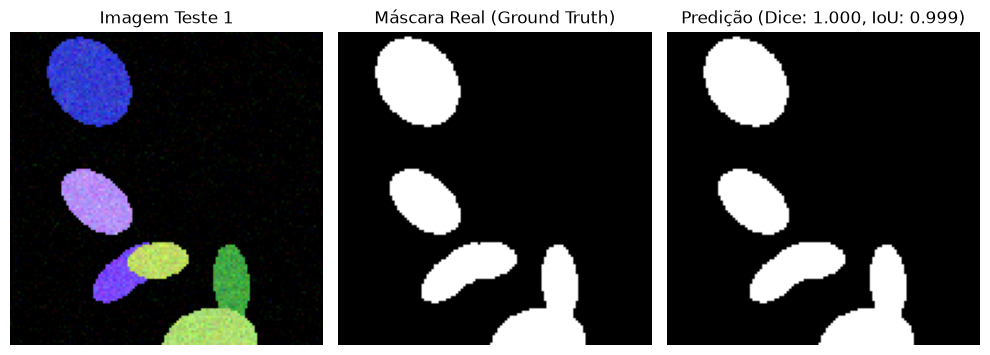

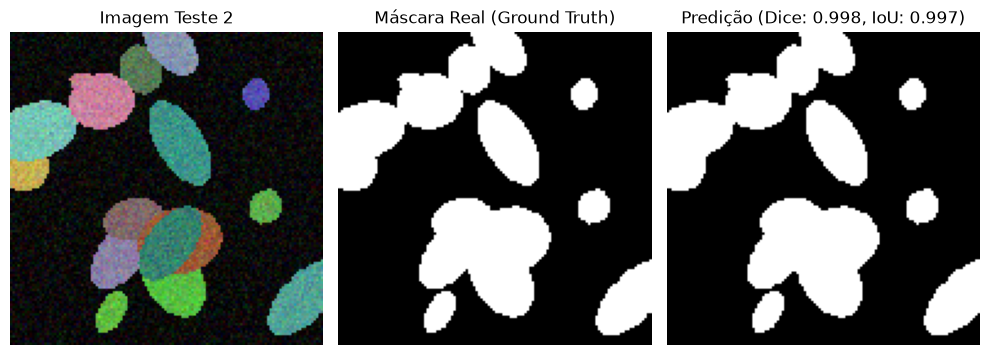

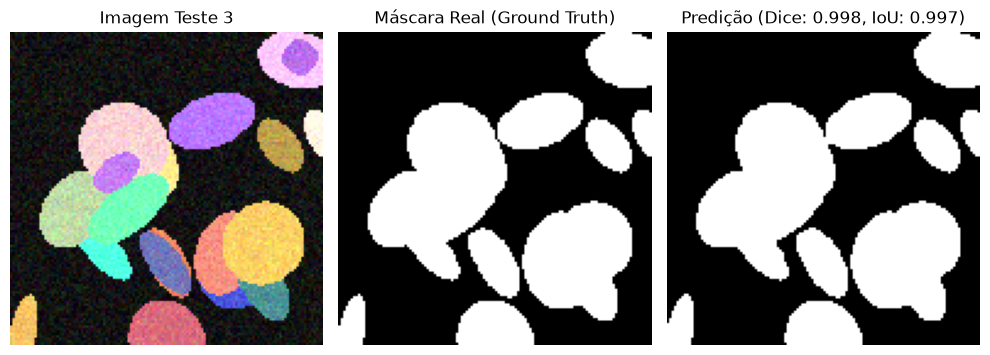

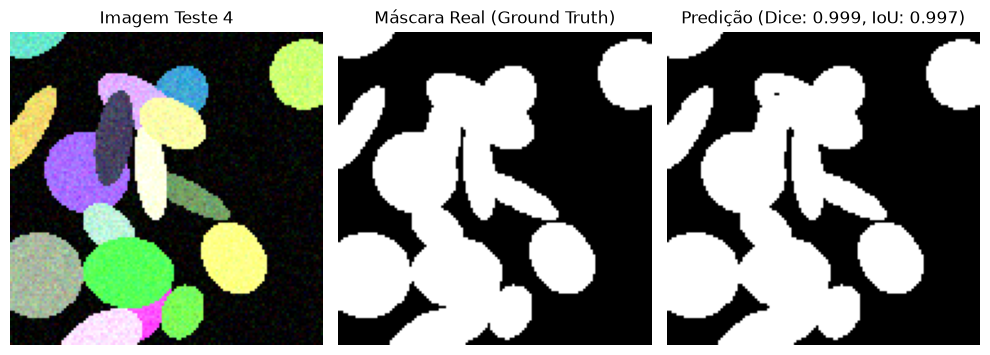

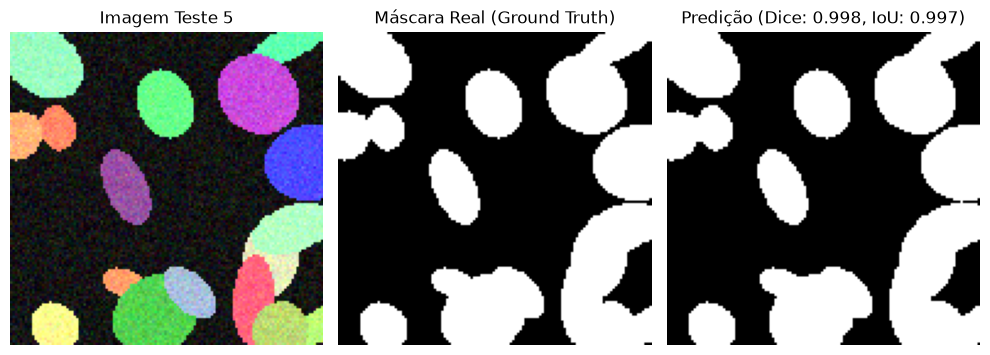

In [98]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)


--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)
> **Enunciados Parte 1:**
> - **Item 1:** Treinar uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportar IoU e Dice.
> - **Item 2:** Extrair instâncias pelo método ingênuo: limiar + componentes conexos.
> - **Item 3:** Avaliar como instâncias. Para cada limiar de IoU de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira, contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportar também o erro absoluto de contagem por imagem.
> - **Item 4:** Documentar a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão números diferentes — a escolha é de vocês, mas tem que estar explícita.
> - **Item 5:** Quantificar o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de objetos na imagem.

In [99]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")


Carregando 670 amostras de '../data/stage1_train'...
Aviso: 298/29461 rótulos de instâncias foram perdidos no resize.
Dataset real carregado em 12.35 segundos!
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


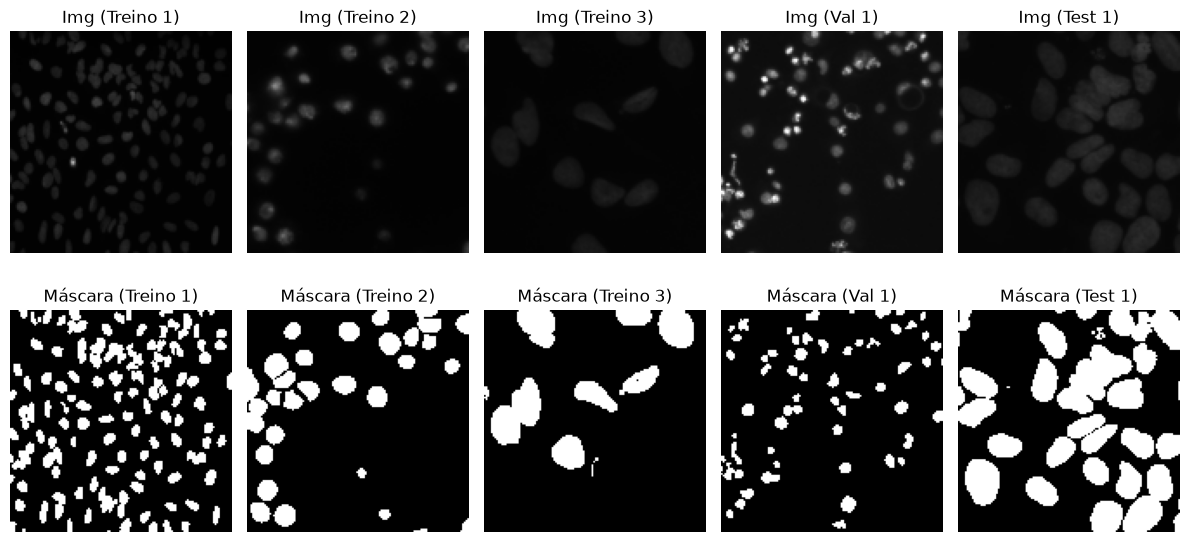

In [100]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)


In [101]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\n[Parte 1 - Item 1] Mean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")


Epoch [ 1/10] | Train Loss: 0.4661 | Val Loss: 0.3978
Epoch [ 2/10] | Train Loss: 0.3027 | Val Loss: 0.2403
Epoch [ 3/10] | Train Loss: 0.2233 | Val Loss: 0.1974
Epoch [ 4/10] | Train Loss: 0.1726 | Val Loss: 0.1520
Epoch [ 5/10] | Train Loss: 0.1402 | Val Loss: 0.1223
Epoch [ 6/10] | Train Loss: 0.1194 | Val Loss: 0.1146
Epoch [ 7/10] | Train Loss: 0.1045 | Val Loss: 0.1201
Epoch [ 8/10] | Train Loss: 0.0940 | Val Loss: 0.1140
Epoch [ 9/10] | Train Loss: 0.0859 | Val Loss: 0.1095
Epoch [10/10] | Train Loss: 0.0794 | Val Loss: 0.1056

[Parte 1 - Item 1] Mean Dice: 0.8796 | Mean IoU: 0.7962


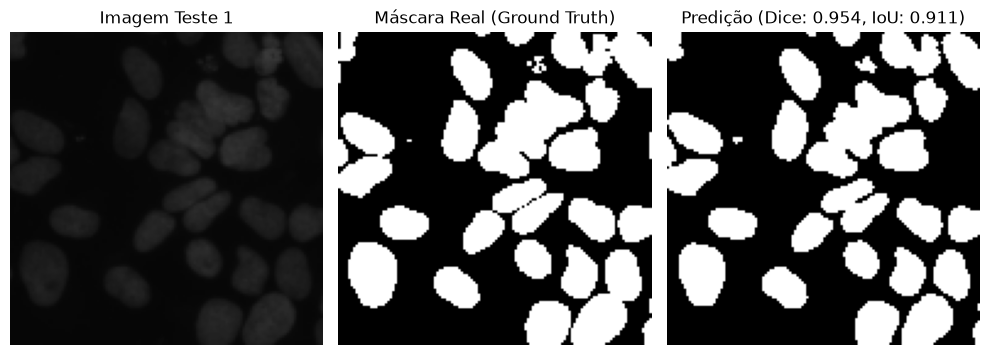

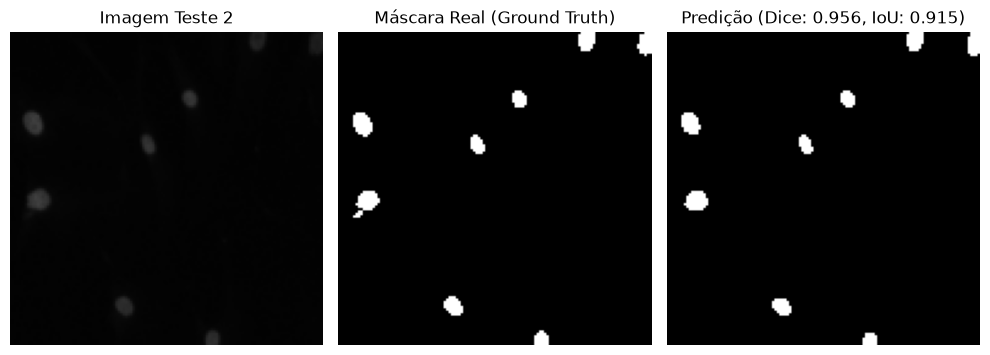

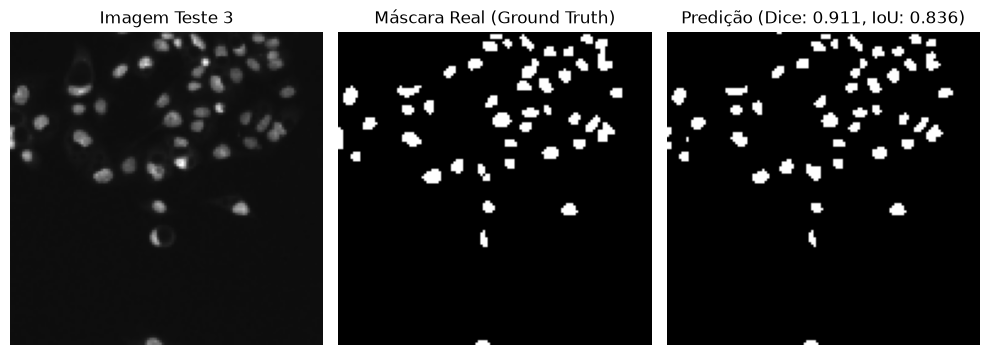

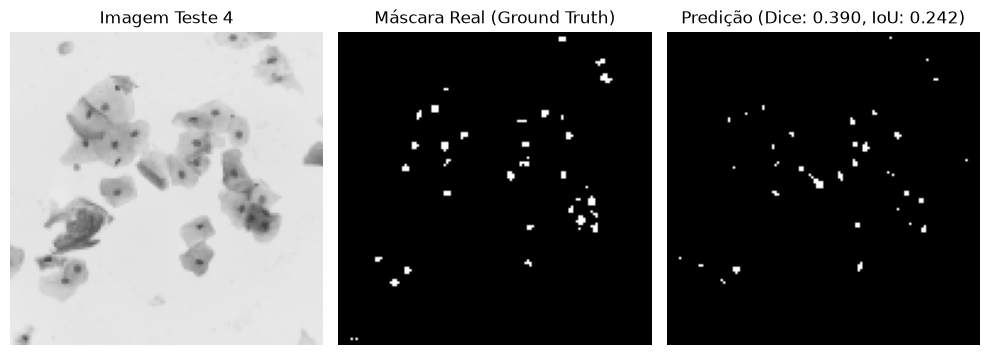

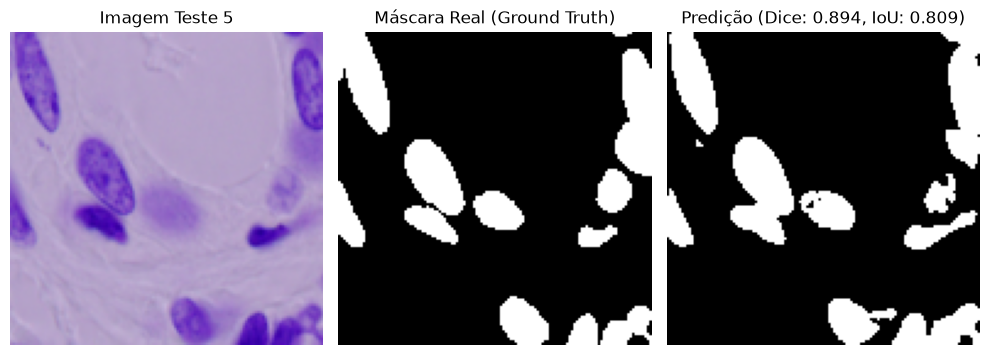

In [102]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)


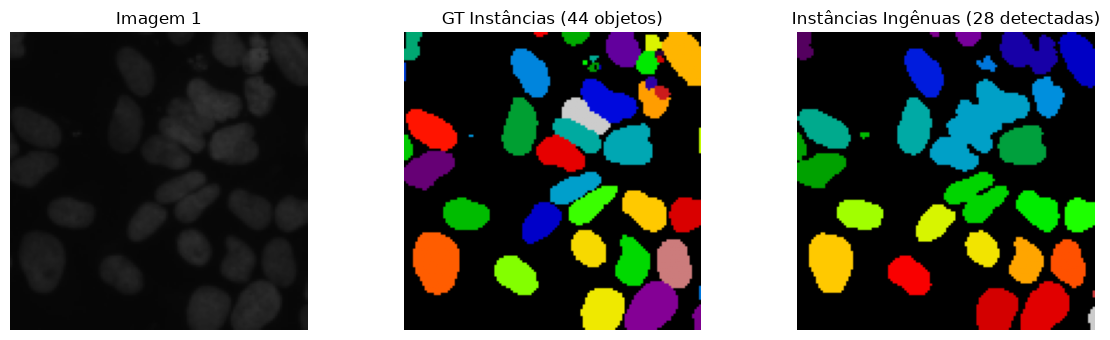

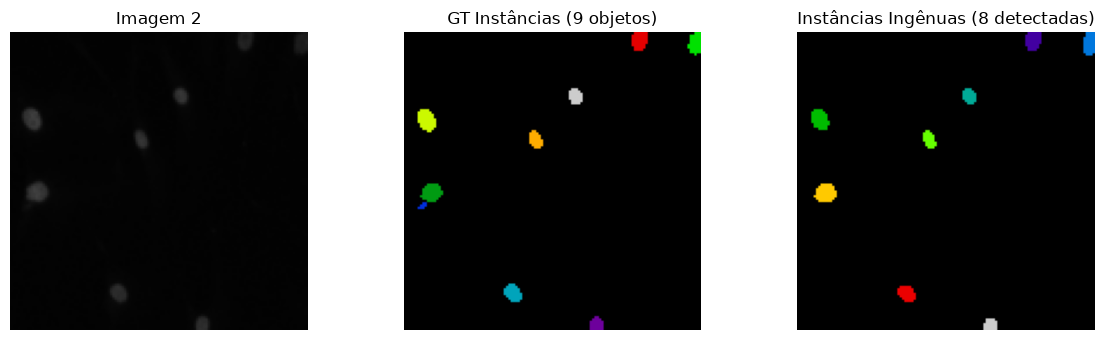

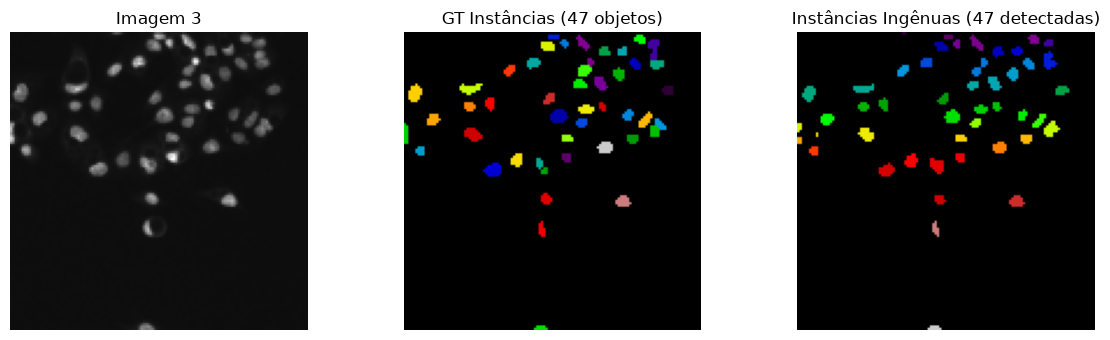

In [103]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


In [104]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6548
  IoU = 0.55 : AP = 0.6094
  IoU = 0.60 : AP = 0.5782
  IoU = 0.65 : AP = 0.5497
  IoU = 0.70 : AP = 0.5097
  IoU = 0.75 : AP = 0.4527
  IoU = 0.80 : AP = 0.3921
  IoU = 0.85 : AP = 0.2953
  IoU = 0.90 : AP = 0.1752
  IoU = 0.95 : AP = 0.0498

--> mAP@[.50:.95] Final: 0.4267
--> Erro Absoluto Médio de Contagem por Imagem: 7.69 objetos


In [105]:
# Parte 1 (Item 4) — Documentação e Comparação da Regra de Matching (Guloso por IoU Decrescente vs. Algoritmo Húngaro)
res_g_real, res_h_real = utils.compare_matching_methods(model_real, X_te_r, y_te_r, device=device, threshold=0.5, dataset_name="Reais (DSB2018)")



--- [Item 4] Comparação da Regra de Matching (Reais (DSB2018)) ---
Guloso (Greedy):    mAP@[.50:.95] = 0.4267 | Erro Médio Contagem = 7.69
Húngaro (Hungarian): mAP@[.50:.95] = 0.4267 | Erro Médio Contagem = 7.69
Regra de matching documentada e explicitada: Algoritmo Húngaro (Hungarian)


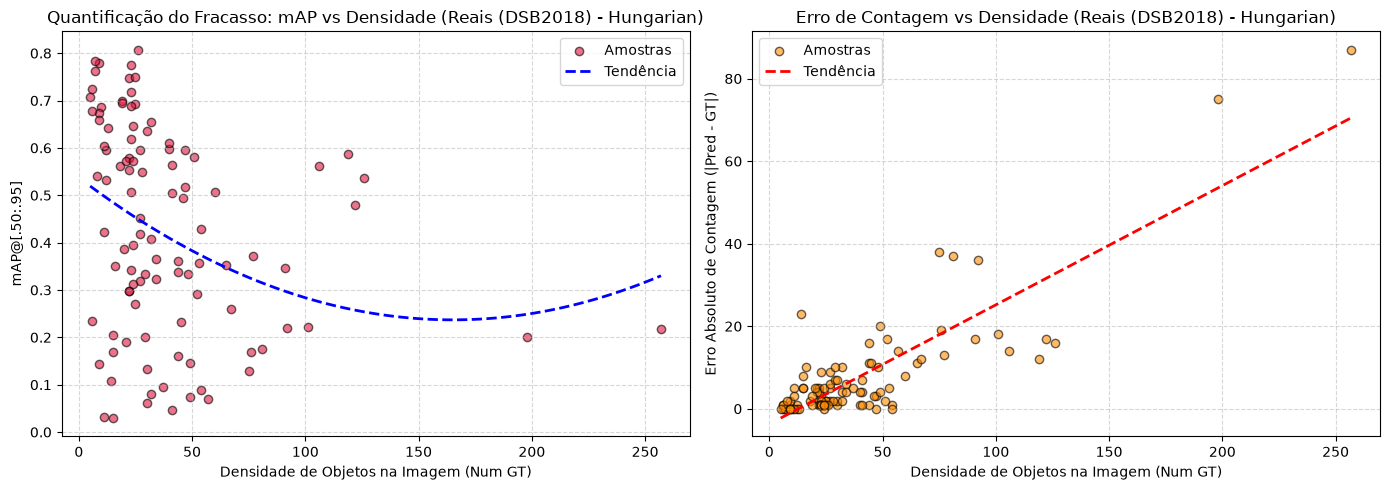

In [106]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")


## Relatório da Parte 1 (Itens 1 a 5)

- **Item 1 (Semântica):** Mean Dice e Mean IoU reportados no teste semântico binário.
- **Item 2 (Extração Ingênua):** Limiar $0.5$ + componentes conexos de 8-conectividade.
- **Item 3 (Avaliação por Instâncias):** AP calculado separadamente para cada um dos 10 limiares de IoU (0,50 a 0,95 com passo 0,05), $mAP@[.50:.95]$ e erro absoluto médio de contagem por imagem.
- **Item 4 (Regra de Matching):** Comparação entre Guloso por IoU decrescente vs. Algoritmo Húngaro (Munkres). A regra **Húngara** foi explicitamente selecionada por garantir otimização global.
- **Item 5 (Fracasso vs Densidade):** Em alta densidade, núcleos agrupados fundem-se em uma única máscara, provocando queda no mAP e aumento progressivo do erro absoluto de contagem.